<a href="https://colab.research.google.com/github/Spurthi-338/6thSem-ML-Lab/blob/main/1BM23CS338_Lab_7_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Default n_estimators = 10
Accuracy: 0.9666666666666667
n_estimators = 5, Accuracy = 0.9333
n_estimators = 10, Accuracy = 0.9667
n_estimators = 20, Accuracy = 0.9333
n_estimators = 50, Accuracy = 0.9000
n_estimators = 100, Accuracy = 0.9000
n_estimators = 150, Accuracy = 0.9000
n_estimators = 200, Accuracy = 0.9000

Best Accuracy: 0.9666666666666667
Best n_estimators: 10


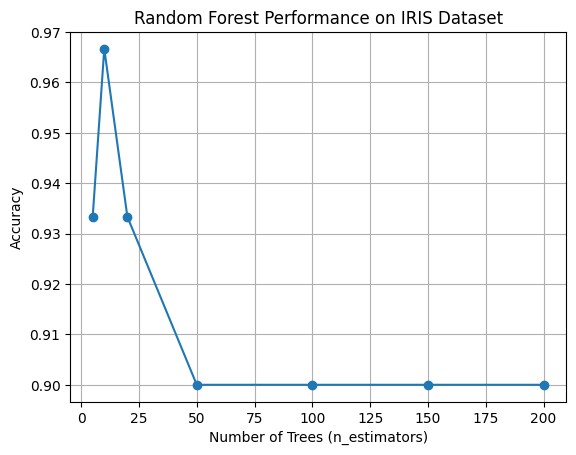

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("iris.csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 1. Default Random Forest (n_estimators = 10)
# -------------------------------
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

print("Default n_estimators = 10")
print("Accuracy:", accuracy_score(y_test, y_pred_default))


# -------------------------------
# 2. Hyperparameter Tuning
# -------------------------------
tree_values = [5, 10, 20, 50, 100, 150, 200]
scores = []

for n in tree_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"n_estimators = {n}, Accuracy = {acc:.4f}")

# Best result
best_score = max(scores)
best_trees = tree_values[scores.index(best_score)]

print("\nBest Accuracy:", best_score)
print("Best n_estimators:", best_trees)


# -------------------------------
# 3. Plot Results
# -------------------------------
plt.plot(tree_values, scores, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Performance on IRIS Dataset")
plt.grid()
plt.show()